## Importing libraries and UNet model

In [9]:
import torch
from image_processing import read_img
from sklearn.model_selection import train_test_split
import os
from UNet import UNet,load_training_patches
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from image_processing import show_img, postproces_pipeline, read_img
from simple_statistics import create_confusions_matrix
import gc
import numpy as np
import cv2

device="cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print(f"Used device: {device}")

#CONSTANTS
INPUT_DIR:str="./images"
MANUAL_DIR:str="./manual1"
MASK_DIR:str="./mask"
SAVED_MODELS:str="./saved_models"

#PATHS
input_images=[INPUT_DIR+"/"+file.name for file in os.scandir(INPUT_DIR) if file.is_file()]
manual_images=[MANUAL_DIR+"/"+file.name for file in os.scandir(MANUAL_DIR) if file.is_file()]
mask_images=[MASK_DIR+"/"+file.name for file in os.scandir("./mask") if file.is_file()]

Used device: cuda


### Checking available memory on GPU

In [5]:
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

    total_vram = torch.cuda.get_device_properties(0).total_memory

    print(f"VRAM: {total_vram / 1024**3:.2f} GB")

NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.00 GB


### Creating the model and the datasets

In [ ]:
model = UNet(1).to(device)
print(f"The model will be trained on {next(model.parameters()).device}")

epochs = 5_000
batch_size = 8
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

X, y = load_training_patches(
    input_images,
    manual_images,
    size=1024,
    patch_size=128,
    percent_of_images=0.80,
    device=device,
    only_green=True
)

X_train_patches, X_test, Y_train_patches, Y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


num_train_samples = X_train_patches.shape[0]

X_train_patches = torch.tensor(X_train_patches, dtype=torch.float32)
Y_train_patches = torch.tensor(Y_train_patches, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
Y_test = torch.tensor(Y_test, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_patches, Y_train_patches),
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test, Y_test),
    batch_size=batch_size,
    shuffle=False
)

old_ang_loss = float("inf")

The model will be trained on cuda:0


### Training model

In [ ]:

print("Started the training")

if X_train_patches.ndim == 3:
    X_train_patches = X_train_patches.unsqueeze(1)
if Y_train_patches.ndim == 3:
    Y_train_patches = Y_train_patches.unsqueeze(1)

num_train_samples = X_train_patches.shape[0]

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    permutation = torch.randperm(num_train_samples)

    for i in range(0, num_train_samples, batch_size):
        indices = permutation[i:i + batch_size]

        batch_x = X_train_patches[indices].float().to(device)
        batch_y = Y_train_patches[indices].float().to(device)

        pred_y = model(batch_x)

        loss = criterion(pred_y, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / max(1, len(permutation) // batch_size)

    if avg_loss < old_ang_loss:
        torch.save(
            model.state_dict(),
            SAVED_MODELS + '/' + 'model_weights_best_found_only_green.pth'
        )

    old_ang_loss = avg_loss

    if avg_loss <= 0.0100:
        break

    if epoch % 100 == 0:
        print(f"Epoch: {epoch + 1} z {epochs} Mean error: {avg_loss:.4f}")

Started the training
Epoch: 1 z 5000 Mean error: 0.3177
Epoch: 101 z 5000 Mean error: 0.0218
Epoch: 201 z 5000 Mean error: 0.0151
Epoch: 301 z 5000 Mean error: 0.0134
Epoch: 401 z 5000 Mean error: 0.0121
Epoch: 501 z 5000 Mean error: 0.0112
Epoch: 601 z 5000 Mean error: 0.0114


KeyboardInterrupt: 

### Saving final version

In [21]:
torch.save(model.state_dict(), SAVED_MODELS+"/"+'model_weights_newest_1024_size_only_green.pth')


### Loading the model and saving it again to ensure everything is correct

In [11]:
model = UNet(1).to(device)
model.load_state_dict(torch.load(SAVED_MODELS+"/"+"model_weights_newest_1024_size_only_green.pth", weights_only=True))

<All keys matched successfully>

### Testing model performance

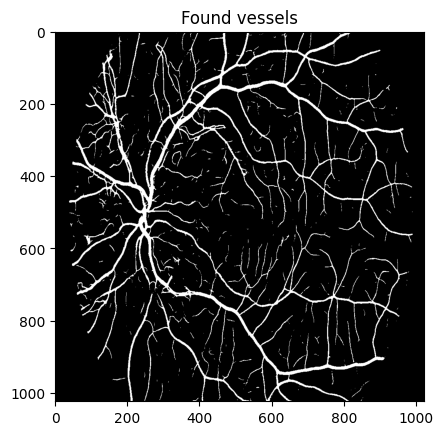

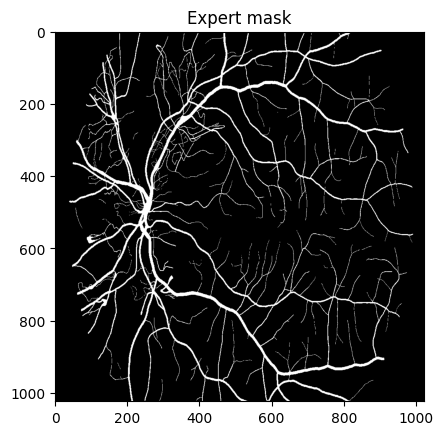

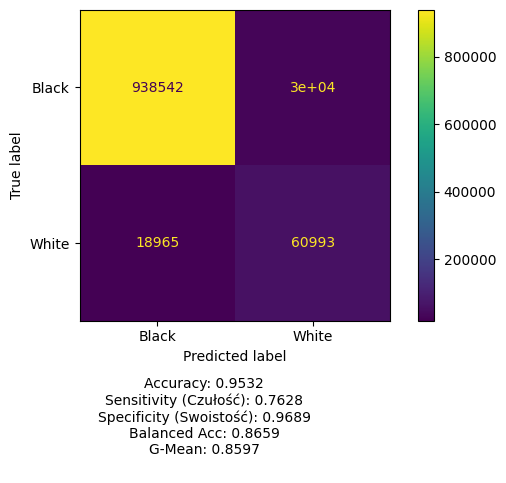

In [13]:
image_path = "./images/14_dr.JPG"
mask_path  = "./manual1/14_dr.tif"

gc.collect()
torch.cuda.empty_cache()

model.eval()

img = read_img(image_path)
mask = read_img(mask_path)

if len(mask.shape) > 1:
    mask = mask[:, :, 1]

size = 1024
img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)

#extract green channel
img = img[:, :, 1].astype(np.float32) / 255.0 


img = np.expand_dims(img, axis=0)
img = np.expand_dims(img, axis=0)

mask = (mask > 0).astype(np.uint8)

X = torch.tensor(img, dtype=torch.float32, device=device)

with torch.no_grad():
    result = model(X)
    result = torch.sigmoid(result)
    result = (result > 0.01).float()

pred = result.squeeze(0).squeeze(0).cpu().numpy().astype(np.uint8)
pred = postproces_pipeline(pred, 3)

show_img(pred,"Found vessels")
true = mask.astype(np.uint8)

show_img(mask,"Expert mask")
h = min(true.shape[0], pred.shape[0])
w = min(true.shape[1], pred.shape[1])

true = true[:h, :w]
pred = pred[:h, :w]

create_confusions_matrix(
    true.flatten(),
    pred.flatten()
)